# `ARIMA model`

In [133]:
# import necessary libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings


# imoprt the ARIMA model from statsmodels
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from pmdarima.arima.utils import ndiffs
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error

# set the style of seaborn
sns.set(style="whitegrid")
warnings.filterwarnings("ignore")

In [134]:
# load the dataset
df = pd.read_csv('WMT.csv')

# run the head 
df.head()

,Date,Adj Close
0,2000-01-03,44.915394
1,2000-01-04,43.234756
2,2000-01-05,42.352402
3,2000-01-06,42.814564
4,2000-01-07,46.049828


In [135]:
# inspecting data types, null values and duplicates
df.info()
display(df.isnull().sum())
display(df.duplicated().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5479 entries, 0 to 5478
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       5479 non-null   object 
 1   Adj Close  5284 non-null   float64
dtypes: float64(1), object(1)
memory usage: 85.7+ KB


Date           0
Adj Close    195
dtype: int64

np.int64(0)

In [136]:
# make a date column as index
df['Date'] = pd.to_datetime(df['Date'])

# set the date column as index
df.set_index('Date', inplace=True)

# change the frequency of the data to daily
df = df.asfreq('B')

# fill the missing values with forward fill method
df = df.ffill()

# check the data info after setting the index and changing the frequency
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 5479 entries, 2000-01-03 to 2020-12-31
Freq: B
Data columns (total 1 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Adj Close  5479 non-null   float64
dtypes: float64(1)
memory usage: 85.6 KB


In [137]:
# keep only the data from 2010 to 2020
df = df['2010':'2020']

In [138]:
# check the time series for stationarity using Augmented Dickey-Fuller test
series = df['Adj Close']

In [139]:
# define a function to run the adf test
def get_adfuller_results(x, name=""):
    x = x.dropna()
    result = adfuller(x)
    print(f"ADF test for {name}")
    print(f"ADF statistic: {result[0]:.4f}")
    print(f"p-value: {result[1]:.4f}")
    print("Stationary" if result[1] < 0.05 else "Non-stationary")
    print() 

In [140]:
# run the adf test on the raw series
get_adfuller_results(series, "raw price")

ADF test for raw price
ADF statistic: 1.4574
p-value: 0.9974
Non-stationary



In [141]:
# use pmdarima ndiffs to suggest the number of differencing
d = ndiffs(series, test="adf")
f"Suggested d: {d}"

'Suggested d: 1'

In [142]:
# apply the differencing
series_diff = series.diff(d).dropna()

In [143]:
# run the adf test again on the differenced series
get_adfuller_results(series_diff, "differenced")

ADF test for differenced
ADF statistic: -12.2140
p-value: 0.0000
Stationary



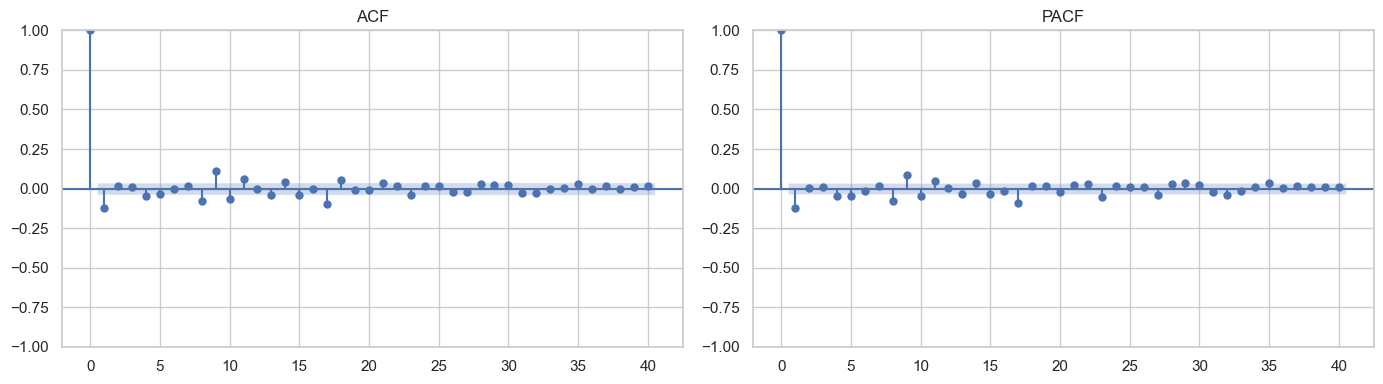

In [144]:
# plot acf and pacf of the differenced series
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# plot the acf and pacf
plot_acf(series_diff, lags=40, ax=axes[0])
plot_pacf(series_diff, lags=40, ax=axes[1])

# set the titles of the plots
axes[0].set_title("ACF")
axes[1].set_title("PACF")
plt.tight_layout()
plt.show()

In [145]:
# define the test size as one quarter of business days
test_size = 13 * 5   # 65 business days

# split into train and test by position (no shuffling)
train = series.iloc[:-test_size]
test = series.iloc[-test_size:]

# check the split
print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Train ends:", train.index[-1].date())
print("Test starts:", test.index[0].date(), "-> ends:", test.index[-1].date())

Train shape: (2805,)
Test shape: (65,)
Train ends: 2020-10-01
Test starts: 2020-10-02 -> ends: 2020-12-31


In [146]:
# fit the arima model on the train data
model = ARIMA(train, order=(0, 1, 0)).fit()

In [147]:
# forecast for the length of the test set
forecast = model.forecast(steps=len(test))

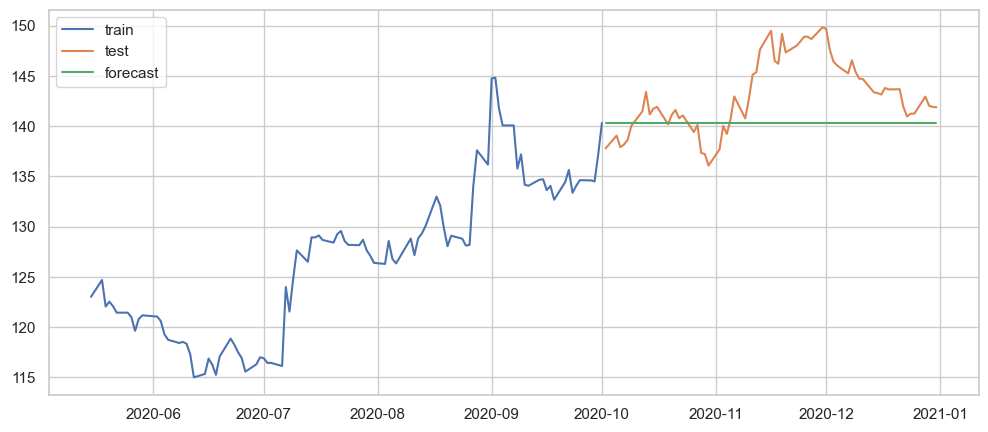

In [148]:
# plot forecast vs test
plt.figure(figsize=(12, 5))
plt.plot(train.index[-100:], train[-100:], label="train")
plt.plot(test.index, test, label="test")
plt.plot(test.index, forecast, label="forecast")
plt.legend();

In [149]:
# evaluation metrics
print("MAPE:", mean_absolute_percentage_error(test, forecast))
print("RMSE:", np.sqrt(mean_squared_error(test, forecast)))

MAPE: 0.02460595542418988
RMSE: 4.538112968135305


In [151]:
# define the orders to try
orders = [(0,1,0), (1,1,0), (0,1,1), (1,1,1), (2,1,2)]

# loop through each order and store the mape
results = []
for order in orders:
    model = ARIMA(train, order=order).fit()
    forecast = model.forecast(steps=len(test))
    mape = mean_absolute_percentage_error(test, forecast)
    results.append((order, mape))
    print(f"ARIMA{order} -> MAPE: {mape:.4f}")

print("------------------")
# show the best order
best = min(results, key=lambda x: x[1])
print("Best order:", best[0], "with MAPE:", round(best[1], 4))

ARIMA(0, 1, 0) -> MAPE: 0.0246
ARIMA(1, 1, 0) -> MAPE: 0.0259
ARIMA(0, 1, 1) -> MAPE: 0.0262
ARIMA(1, 1, 1) -> MAPE: 0.0257
ARIMA(2, 1, 2) -> MAPE: 0.0250
------------------
Best order: (0, 1, 0) with MAPE: 0.0246


## Final Model: ARIMA(0,1,0)

> **Why this model:** It gave the lowest MAPE (2.46%) and is the simplest of all orders tried. Adding AR/MA terms (1,1,1), (2,1,2), etc. did not improve results — confirming the series behaves like a random walk, where the best predictor of tomorrow's price is today's price.

> **How good by MAPE?** Very good. A MAPE of **2.46%** means the forecast was on average within ~2.5% of the true price over the 65-day test quarter — strong numerical accuracy.

> **How good visually?** Poor. The forecast is a **flat horizontal line** at the last training price, while the real test data moves up and down daily. The model captures the price *level* but not its *direction or volatility* — expected behavior for a random walk on stock data.

> **Takeaway:** Low MAPE reflects that Walmart's price didn't drift far over the quarter, not genuine predictive skill about where the stock is headed.